In [1]:
!pip install datasets seaborn great-expectations

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Selection**

The Titanic dataset was selected because it is a structured tabular dataset with both numerical and categorical features. Its moderate size (891 rows) makes it suitable for efficient exploratory data analysis. The dataset also contains missing values and heterogeneous data types, which are useful for demonstrating data profiling and validation using Great Expectations.

In [3]:
from datasets import load_dataset

dataset = load_dataset("phihung/titanic")
df = dataset['train'].to_pandas()

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S


  return datetime.utcnow().replace(tzinfo=utc)



In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


  return datetime.utcnow().replace(tzinfo=utc)



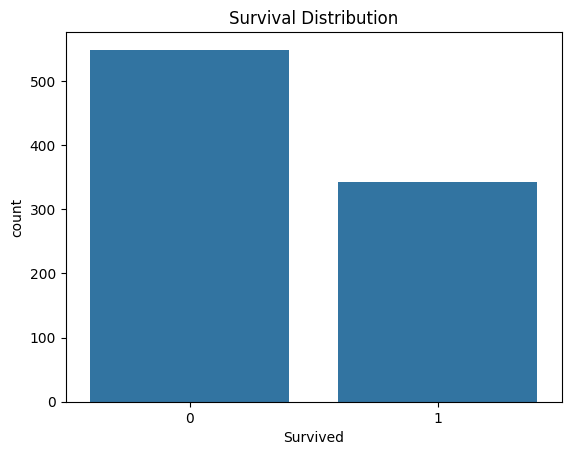

In [27]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution")
plt.show()

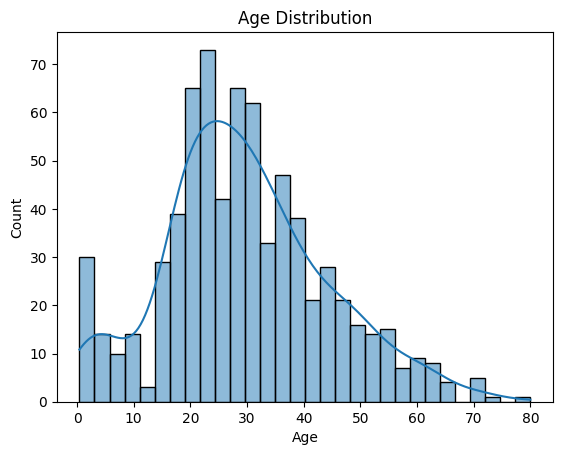

In [9]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

  return datetime.utcnow().replace(tzinfo=utc)



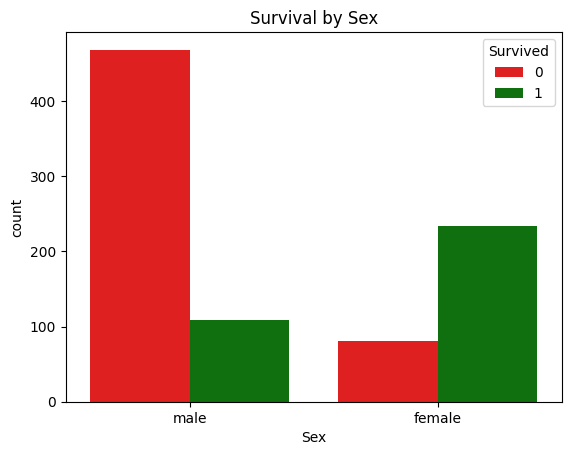

In [25]:
sns.countplot(x="Sex", hue="Survived", data=df, palette={0: "red", 1: "green"})
plt.title("Survival by Sex")
plt.show()

  return datetime.utcnow().replace(tzinfo=utc)

  return datetime.utcnow().replace(tzinfo=utc)



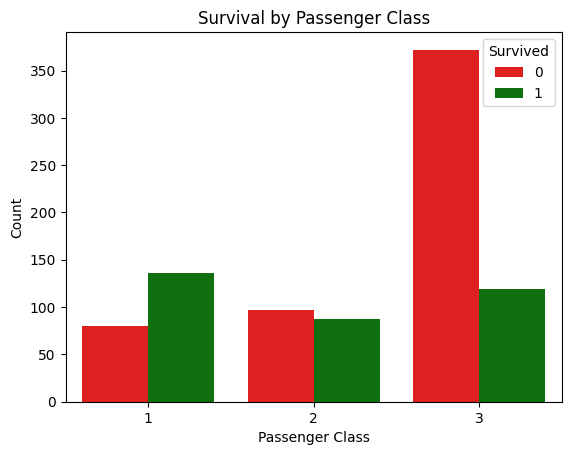

In [24]:
sns.countplot(x="Pclass", hue="Survived", data=df, palette={0: "red", 1: "green"})
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

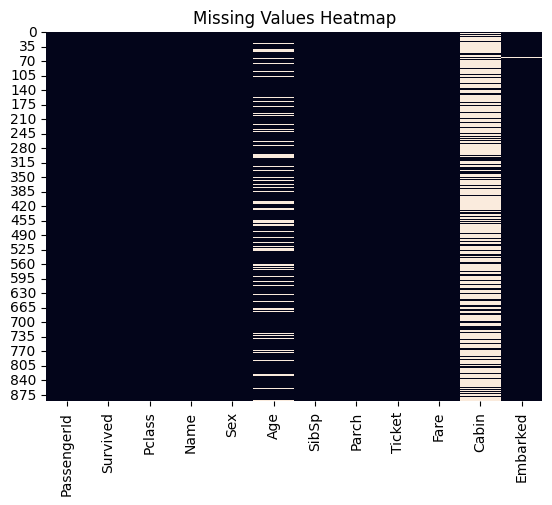

In [11]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [22]:
import great_expectations as ge

df_ge = ge.from_pandas(df)

df_ge.expect_column_values_to_not_be_null("Survived")
df_ge.expect_column_values_to_be_in_set("Sex", ["male", "female"])
df_ge.expect_column_values_to_be_between("Fare", min_value=0)
df_ge.expect_column_values_to_not_be_null("Pclass")

results = df_ge.validate()
results

{
  "success": true,
  "results": [
    {
      "success": true,
      "expectation_config": {
        "expectation_type": "expect_column_values_to_not_be_null",
        "kwargs": {
          "column": "Survived",
          "result_format": "BASIC"
        },
        "meta": {}
      },
      "result": {
        "element_count": 891,
        "unexpected_count": 0,
        "unexpected_percent": 0.0,
        "unexpected_percent_total": 0.0,
        "partial_unexpected_list": []
      },
      "meta": {},
      "exception_info": {
        "raised_exception": false,
        "exception_message": null,
        "exception_traceback": null
      }
    },
    {
      "success": true,
      "expectation_config": {
        "expectation_type": "expect_column_values_to_be_in_set",
        "kwargs": {
          "column": "Sex",
          "value_set": [
            "male",
            "female"
          ],
          "result_format": "BASIC"
        },
        "meta": {}
      },
      "result": {
   

**Data Quality Analysis (Great Expectations)**

Great Expectations was used to validate data quality on key columns. Expectations confirmed non-null values for critical fields (Survived, Pclass), validated categorical consistency for Sex, and ensured non-negative values for Fare. The validation highlighted missing values in some attributes, indicating the need for preprocessing before modeling.

**Insights**:

* Dataset contains 891 passenger records with mixed numerical and categorical features.

* Missing values are present, notably in Age and Cabin.
* Survival outcome is imbalanced.
* Female passengers show higher survival rates.
* Fare distribution is right-skewed with outliers.
* Dataset is suitable for classification after preprocessing.



